# Studying Chemical Data using RDKit

In [ ]:
!pip install rdkit
from rdkit import Chem
import rdkit
rdkit.__version__
import numpy as np

# SMILES strings

Try "CCCCC", "CCOCC", "CCNCC", "CCSCC"

In [ ]:

new_mol = Chem.MolFromSmiles('CCCCO')
new_mol

**Bonds:** Single, double, and triple bonds are represented by the symbols -, =, and #, respectively.
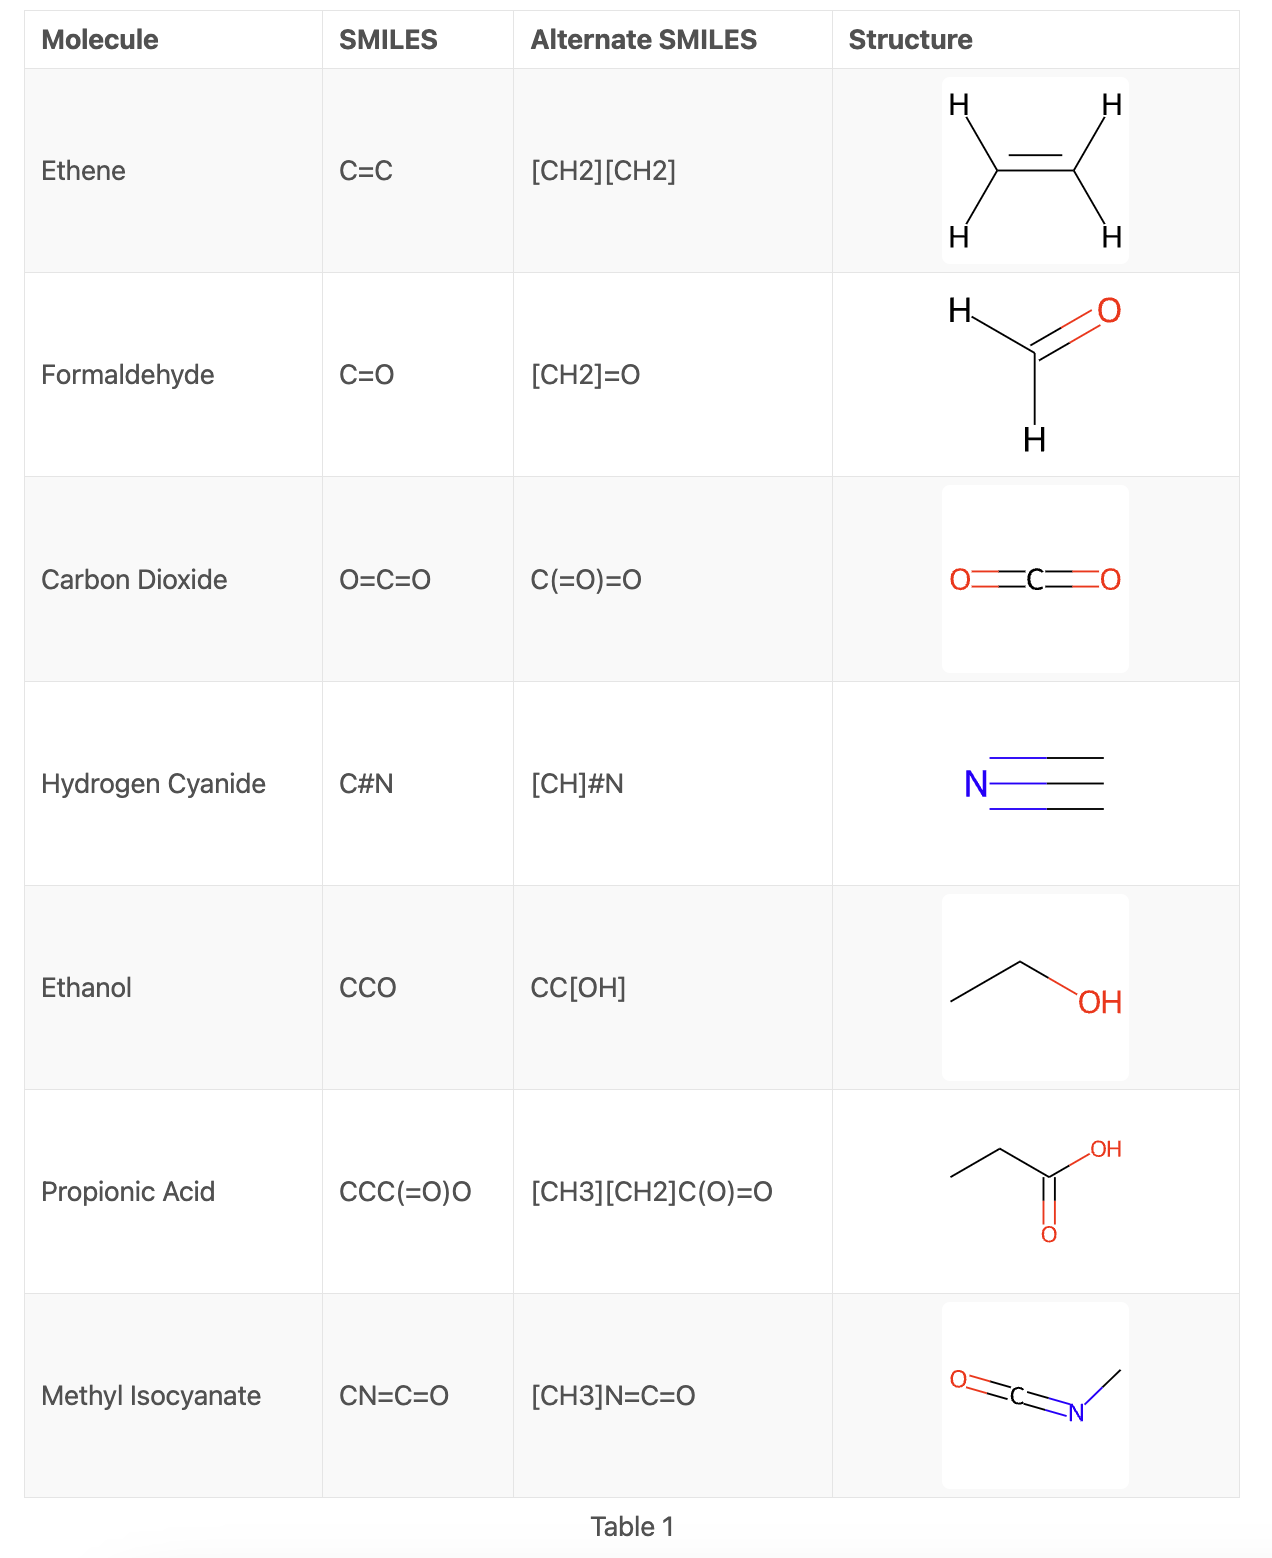

In [ ]:
new_mol = Chem.MolFromSmiles('C-C-C=O')
new_mol

Branched Molecules: parentheses indicate a branch in the molecule.

In [ ]:
new_mol = Chem.MolFromSmiles('CCC(=O)O')
new_mol

Cyclic Structures/Ring Molecules

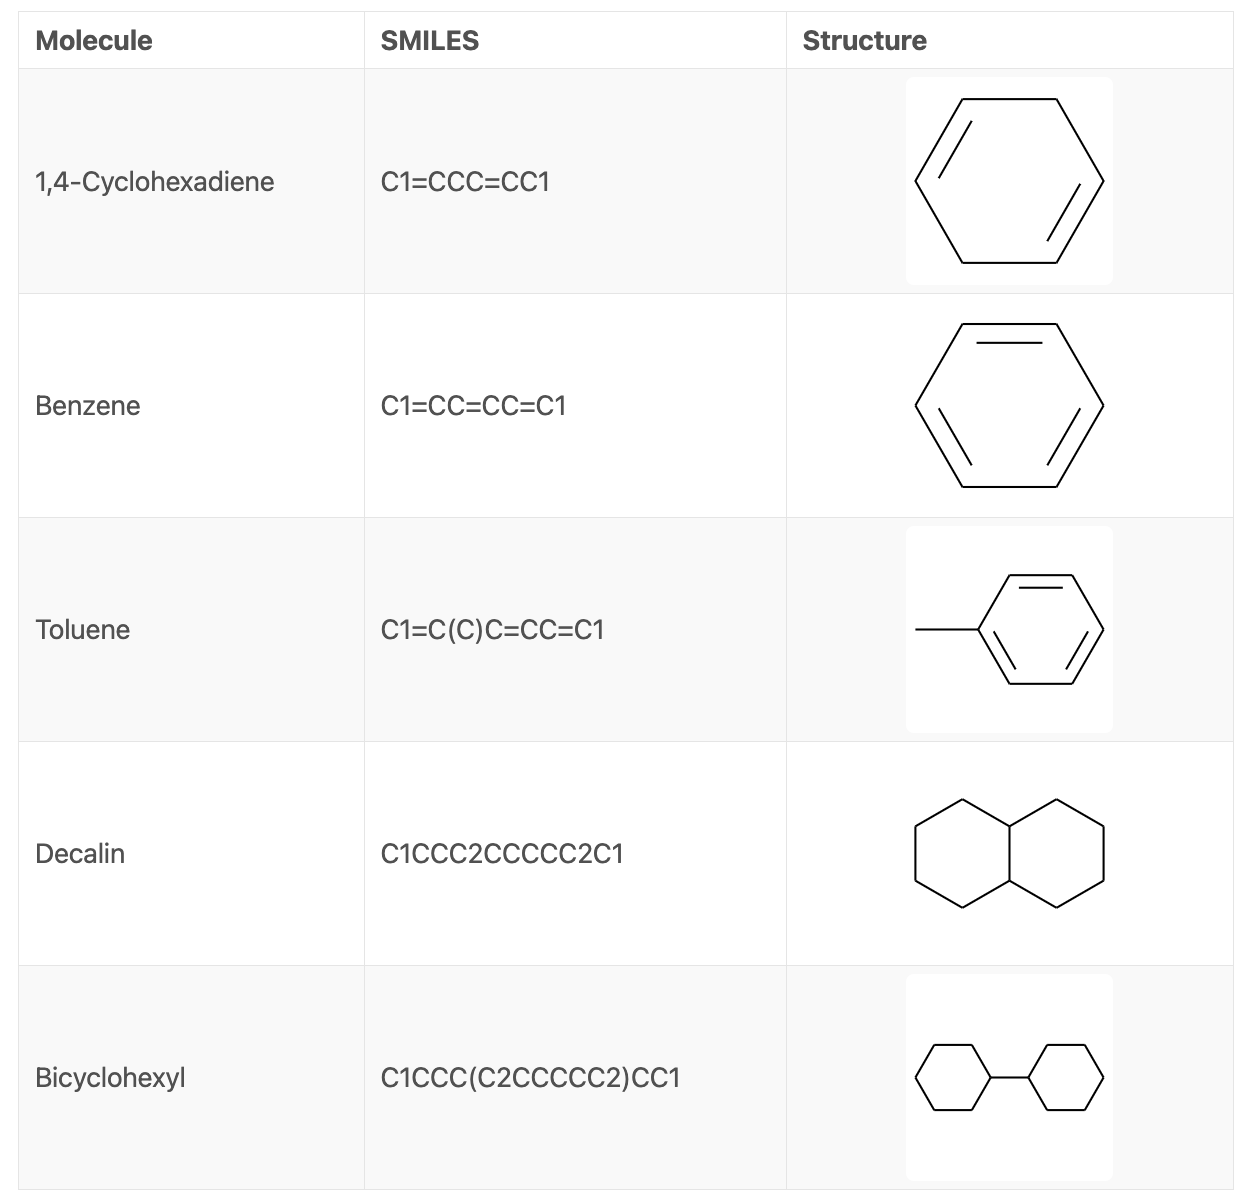

In [ ]:
new_mol = Chem.MolFromSmiles('C1CCCCC1')
new_mol

Aromatic Molecules: The aromatic compounds can be represented by the methods we have learned so far. However, there is a preferred way to represent them: aromatic atoms are represented by lowercase letters.

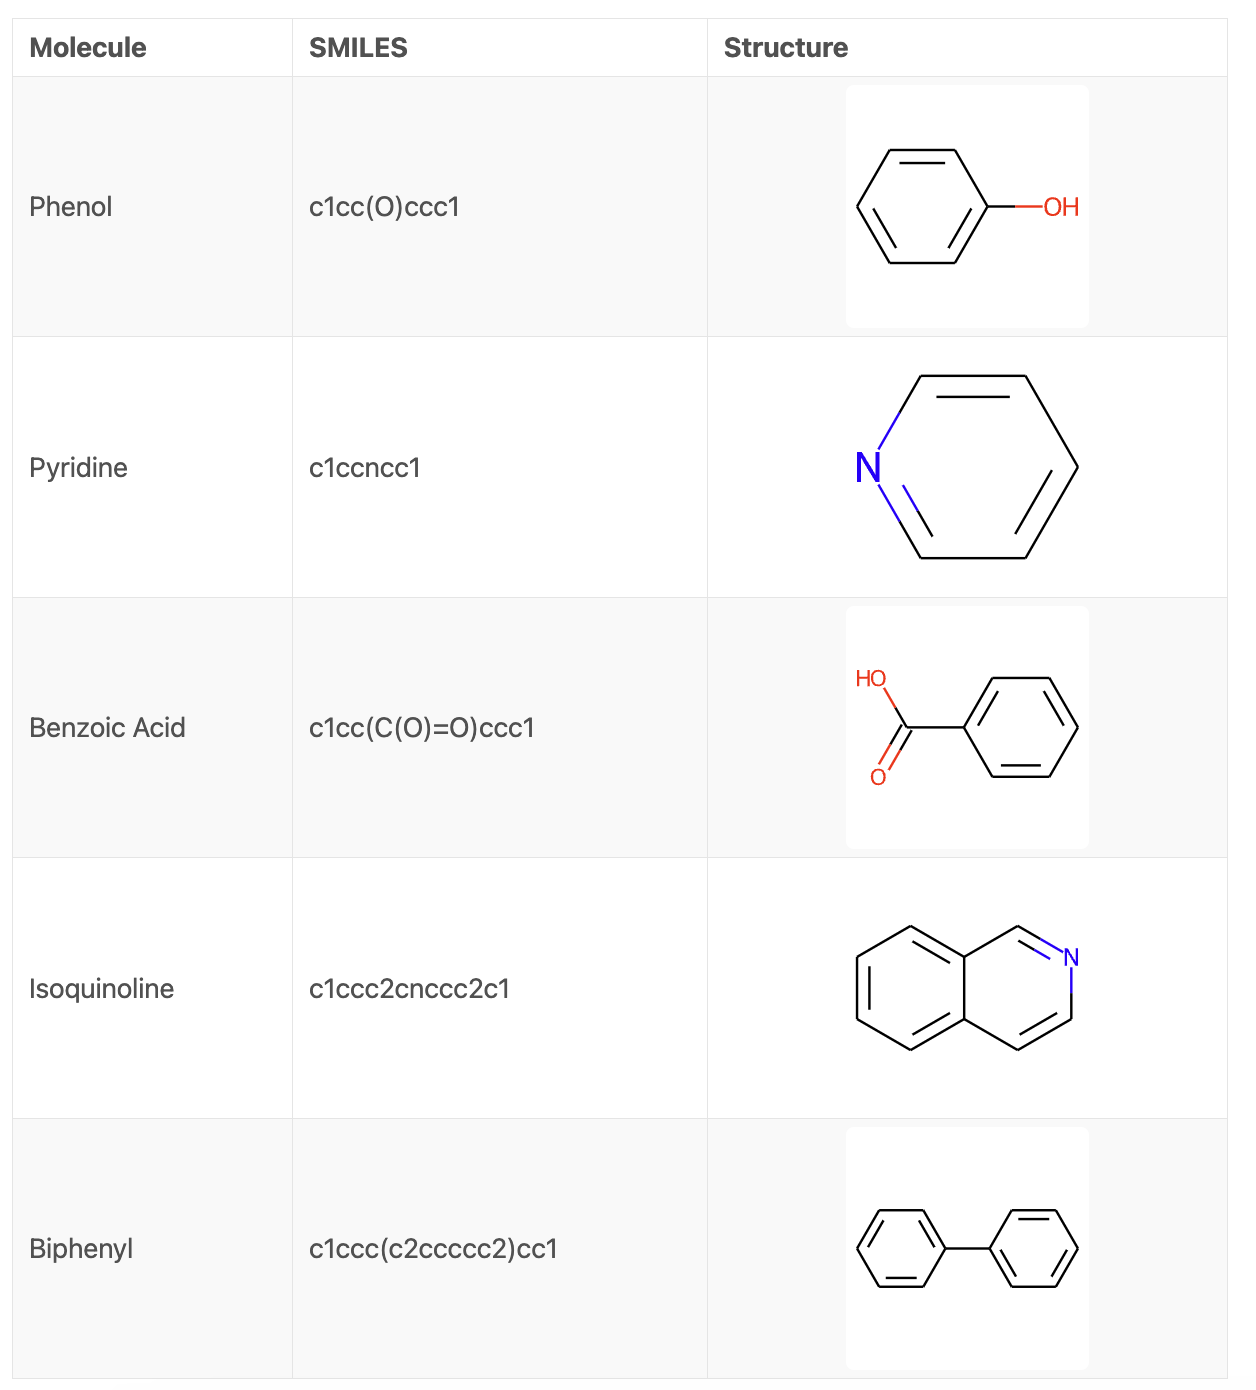

In [ ]:
new_mol = Chem.MolFromSmiles('c1ccccc1')
new_mol

# Molecular descriptors using RdKit

List of Descriptors: https://www.rdkit.org/docs/source/rdkit.Chem.Descriptors.html#

In [ ]:
doravirine = Chem.MolFromSmiles('Cn1c(n[nH]c1=O)Cn2ccc(c(c2=O)Oc3cc(cc(c3)Cl)C#N)C(F)(F)F')
doravirine

In [ ]:
from rdkit.Chem import Descriptors
print(len(Descriptors._descList))

#The list of descriptors can be found in _desclist



In [ ]:
for name, property_value in Descriptors._descList:
  print(name, property_value(doravirine))

In [ ]:
#molecular weight
print('Molecular Weight',Descriptors.MolWt(doravirine))

#number of valence electrons
print('Number of Valence Electrons:',Descriptors.NumValenceElectrons(doravirine))

#number of rings
print('Number of Rings:',Descriptors.RingCount(doravirine))

In [ ]:
import pandas as pd

df = pd.read_csv('toxicity_data.csv')

df.head()

In [ ]:
mol_smiles = df[['smiles']].values[:,0]
mol_smiles

In [ ]:
toxicity = df[['CT_TOX']].values[:,0]
toxicity

# Continue

In [ ]:
#Moleculat Weight
molecwt = [Descriptors.MolWt(Chem.MolFromSmiles(m)) for m in mol_smiles]

#Number of Hydrogen Bond Acceptors
HBond_Acceptors = [Descriptors.NumHAcceptors(Chem.MolFromSmiles(m)) for m in mol_smiles]

#Number of Rotatable Bonds
rot_bonds = [Descriptors.NumRotatableBonds(Chem.MolFromSmiles(m)) for m in mol_smiles]

#Polar Surface Area
polarSA = [Descriptors.TPSA(Chem.MolFromSmiles(m)) for m in mol_smiles]



In [ ]:
dataset = pd.DataFrame({'Mol Wt': molecwt, 'Num HBond Acceptors': HBond_Acceptors, 'Num Rotatable Bonds': rot_bonds, 'Polar Surface Area': polarSA, 'Toxicity': toxicity})
dataset.head()

In [ ]:
import seaborn as sns
sns.pairplot(dataset,hue='Toxicity')